# Climate Resilience Risk Prediction using Random Forest

This notebook develops and interprets a Random Forest regression model to predict composite climate resilience risk from ND-GAIN indicators.

## Workflow
1. Load and prepare data
2. Feature engineering
3. Train/test split
4. Model training & evaluation
5. Global feature importance
6. SHAP model interpretation
7. Feature dependence analysis
8. Conclusions


# Climate Resilience Risk Prediction with Random Forest
This notebook trains and interprets a Random Forest model for the climate resilience project.

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../../data/outputs/all_indicator_values.csv")

In [3]:
# Target
target = (
    df[df["indicator"] == "CompositeRisk"]
    [["country", "year", "value"]]
    .rename(columns={"value": "CompositeRisk"})
)

# Features
features = df[df["indicator"] != "CompositeRisk"].copy()


In [4]:
features = features.pivot(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()

features["Economic"] = 1 - features["Economic"]
features["Governance"] = 1 - features["Governance"]
features["Social"] = 1 - features["Social"]


In [5]:
features

indicator,country,year,Capacity,Economic,Ecosystems,Exposure,Food,Governance,Habitat,Health,Infrastructure,Readiness,Sensitivity,Social,Vulnerability,Water
0,AFG,1995,0.893281,0.503503,0.515884,0.480512,0.665745,0.871910,0.602933,0.748302,0.355586,0.308182,0.419587,0.700042,0.591376,0.529692
1,AFG,1996,0.893892,0.503503,0.516995,0.480512,0.665583,0.871910,0.604235,0.748302,0.354484,0.308180,0.419307,0.700046,0.591385,0.528281
2,AFG,1997,0.894459,0.503503,0.518030,0.480512,0.665420,0.858608,0.605583,0.748302,0.353925,0.312614,0.419055,0.700048,0.591453,0.526853
3,AFG,1998,0.890161,0.503503,0.518156,0.480512,0.657103,0.845306,0.606909,0.748302,0.353710,0.317047,0.418794,0.700051,0.589820,0.525424
4,AFG,1999,0.885896,0.503503,0.518156,0.480512,0.648959,0.856311,0.608137,0.748302,0.352292,0.313378,0.419433,0.700053,0.588345,0.525585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8551,ZWE,2036,0.492703,0.739765,0.512340,0.516912,0.546805,0.870769,0.545288,0.697502,0.127529,0.187447,0.444517,0.827124,0.469816,0.391843
8552,ZWE,2037,0.486468,0.739768,0.512300,0.516912,0.545923,0.870928,0.545246,0.697325,0.116114,0.188199,0.446060,0.824706,0.467660,0.391844
8553,ZWE,2038,0.480233,0.739771,0.512266,0.516912,0.545040,0.871069,0.545212,0.697149,0.104699,0.188957,0.447602,0.822288,0.465506,0.391845
8554,ZWE,2039,0.473998,0.739773,0.512236,0.516912,0.544158,0.871192,0.545186,0.696972,0.093284,0.189721,0.449144,0.819871,0.463353,0.391845


## 1. Data Preparation

In [6]:
dataset = features.merge(target, on=["country", "year"])
dataset = dataset.set_index(["country", "year"])

# Exclude composite metrics that dominate the target
excluded_features = ["Vulnerability", "Readiness"]
dataset = dataset.drop(columns=excluded_features)

In [22]:
X = dataset.drop(columns="CompositeRisk")

In [23]:
y = dataset["CompositeRisk"]


In [7]:
test_years = 5

train = (
    dataset.groupby(level="country")
           .apply(lambda df: df.iloc[:-test_years])
           .reset_index(level=0, drop=True)
)

test = (
    dataset.groupby(level="country")
           .apply(lambda df: df.iloc[-test_years:])
           .reset_index(level=0, drop=True)
)

X_train = train.drop(columns="CompositeRisk")
y_train = train["CompositeRisk"]

X_test = test.drop(columns="CompositeRisk")
y_test = test["CompositeRisk"]

In [8]:
# No readiness correction needed because Readiness is excluded
X_corrected_train = X_train.copy()
X_corrected_test = X_test.copy()

## 2. Train/Test Split

In [9]:
# Approach A: Train on original indicators
rf_corrected = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [10]:
rf_corrected.fit(X_corrected_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred_corr = rf_corrected.predict(X_corrected_test)
r2_corrected = r2_score(y_test, y_pred_corr)
print(f"RF (excluding Vulnerability & Readiness): R² = {r2_corrected:.4f}")


RF (excluding Vulnerability & Readiness): R² = 0.9752


In [12]:
feature_names = dataset.drop(columns="CompositeRisk").columns

## 3. Random Forest Model
Train the model, evaluate predictive performance, and compare impurity-based feature importance with PCA-derived weights.

In [13]:
print("feature_names:", len(feature_names))
print("RF importances:", len(rf_corrected.feature_importances_))
print(feature_names)

feature_names: 12
RF importances: 12
Index(['Capacity', 'Economic', 'Ecosystems', 'Exposure', 'Food', 'Governance',
       'Habitat', 'Health', 'Infrastructure', 'Sensitivity', 'Social',
       'Water'],
      dtype='object')


In [14]:
# Load previously saved PCA weights
weights_df = pd.read_csv("../../config/risk_score_weights.csv")
weights_df = weights_df.rename(columns={"PC1": "PC1_Loading","Unnamed: 0": "Feature"})

In [15]:
weights_df

,Feature,PC1_Loading
0,Capacity,0.380948
1,Economic,0.255446
2,Ecosystems,0.296086
3,Exposure,0.234249
4,Food,0.362303
5,Governance,0.297012
6,Habitat,0.263251
7,Health,0.371920
8,Infrastructure,0.117250
9,Sensitivity,0.283545


In [16]:
# Random Forest importance
rf_df = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_corrected.feature_importances_
})

# Merge RF importances with saved PCA loadings
importance_df = (
    rf_df
    .merge(weights_df[["Feature", "PC1_Loading"]], on="Feature", how="left")
    .sort_values("RF_Importance", ascending=False)
)

print(importance_df)

           Feature  RF_Importance  PC1_Loading
7           Health       0.424533     0.371920
4             Food       0.217371     0.362303
0         Capacity       0.096436     0.380948
3         Exposure       0.085810     0.234249
9      Sensitivity       0.032136     0.283545
11           Water       0.028232     0.181449
8   Infrastructure       0.026927     0.117250
5       Governance       0.026786     0.297012
2       Ecosystems       0.024008     0.296086
1         Economic       0.022256     0.255446
6          Habitat       0.008268     0.263251
10          Social       0.007237     0.304816


In [17]:
print(len(feature_names))
print(len(rf_corrected.feature_importances_))
print(len(weights_df))

12
12
12


### TEST SET MODEL VISUALISATIONS

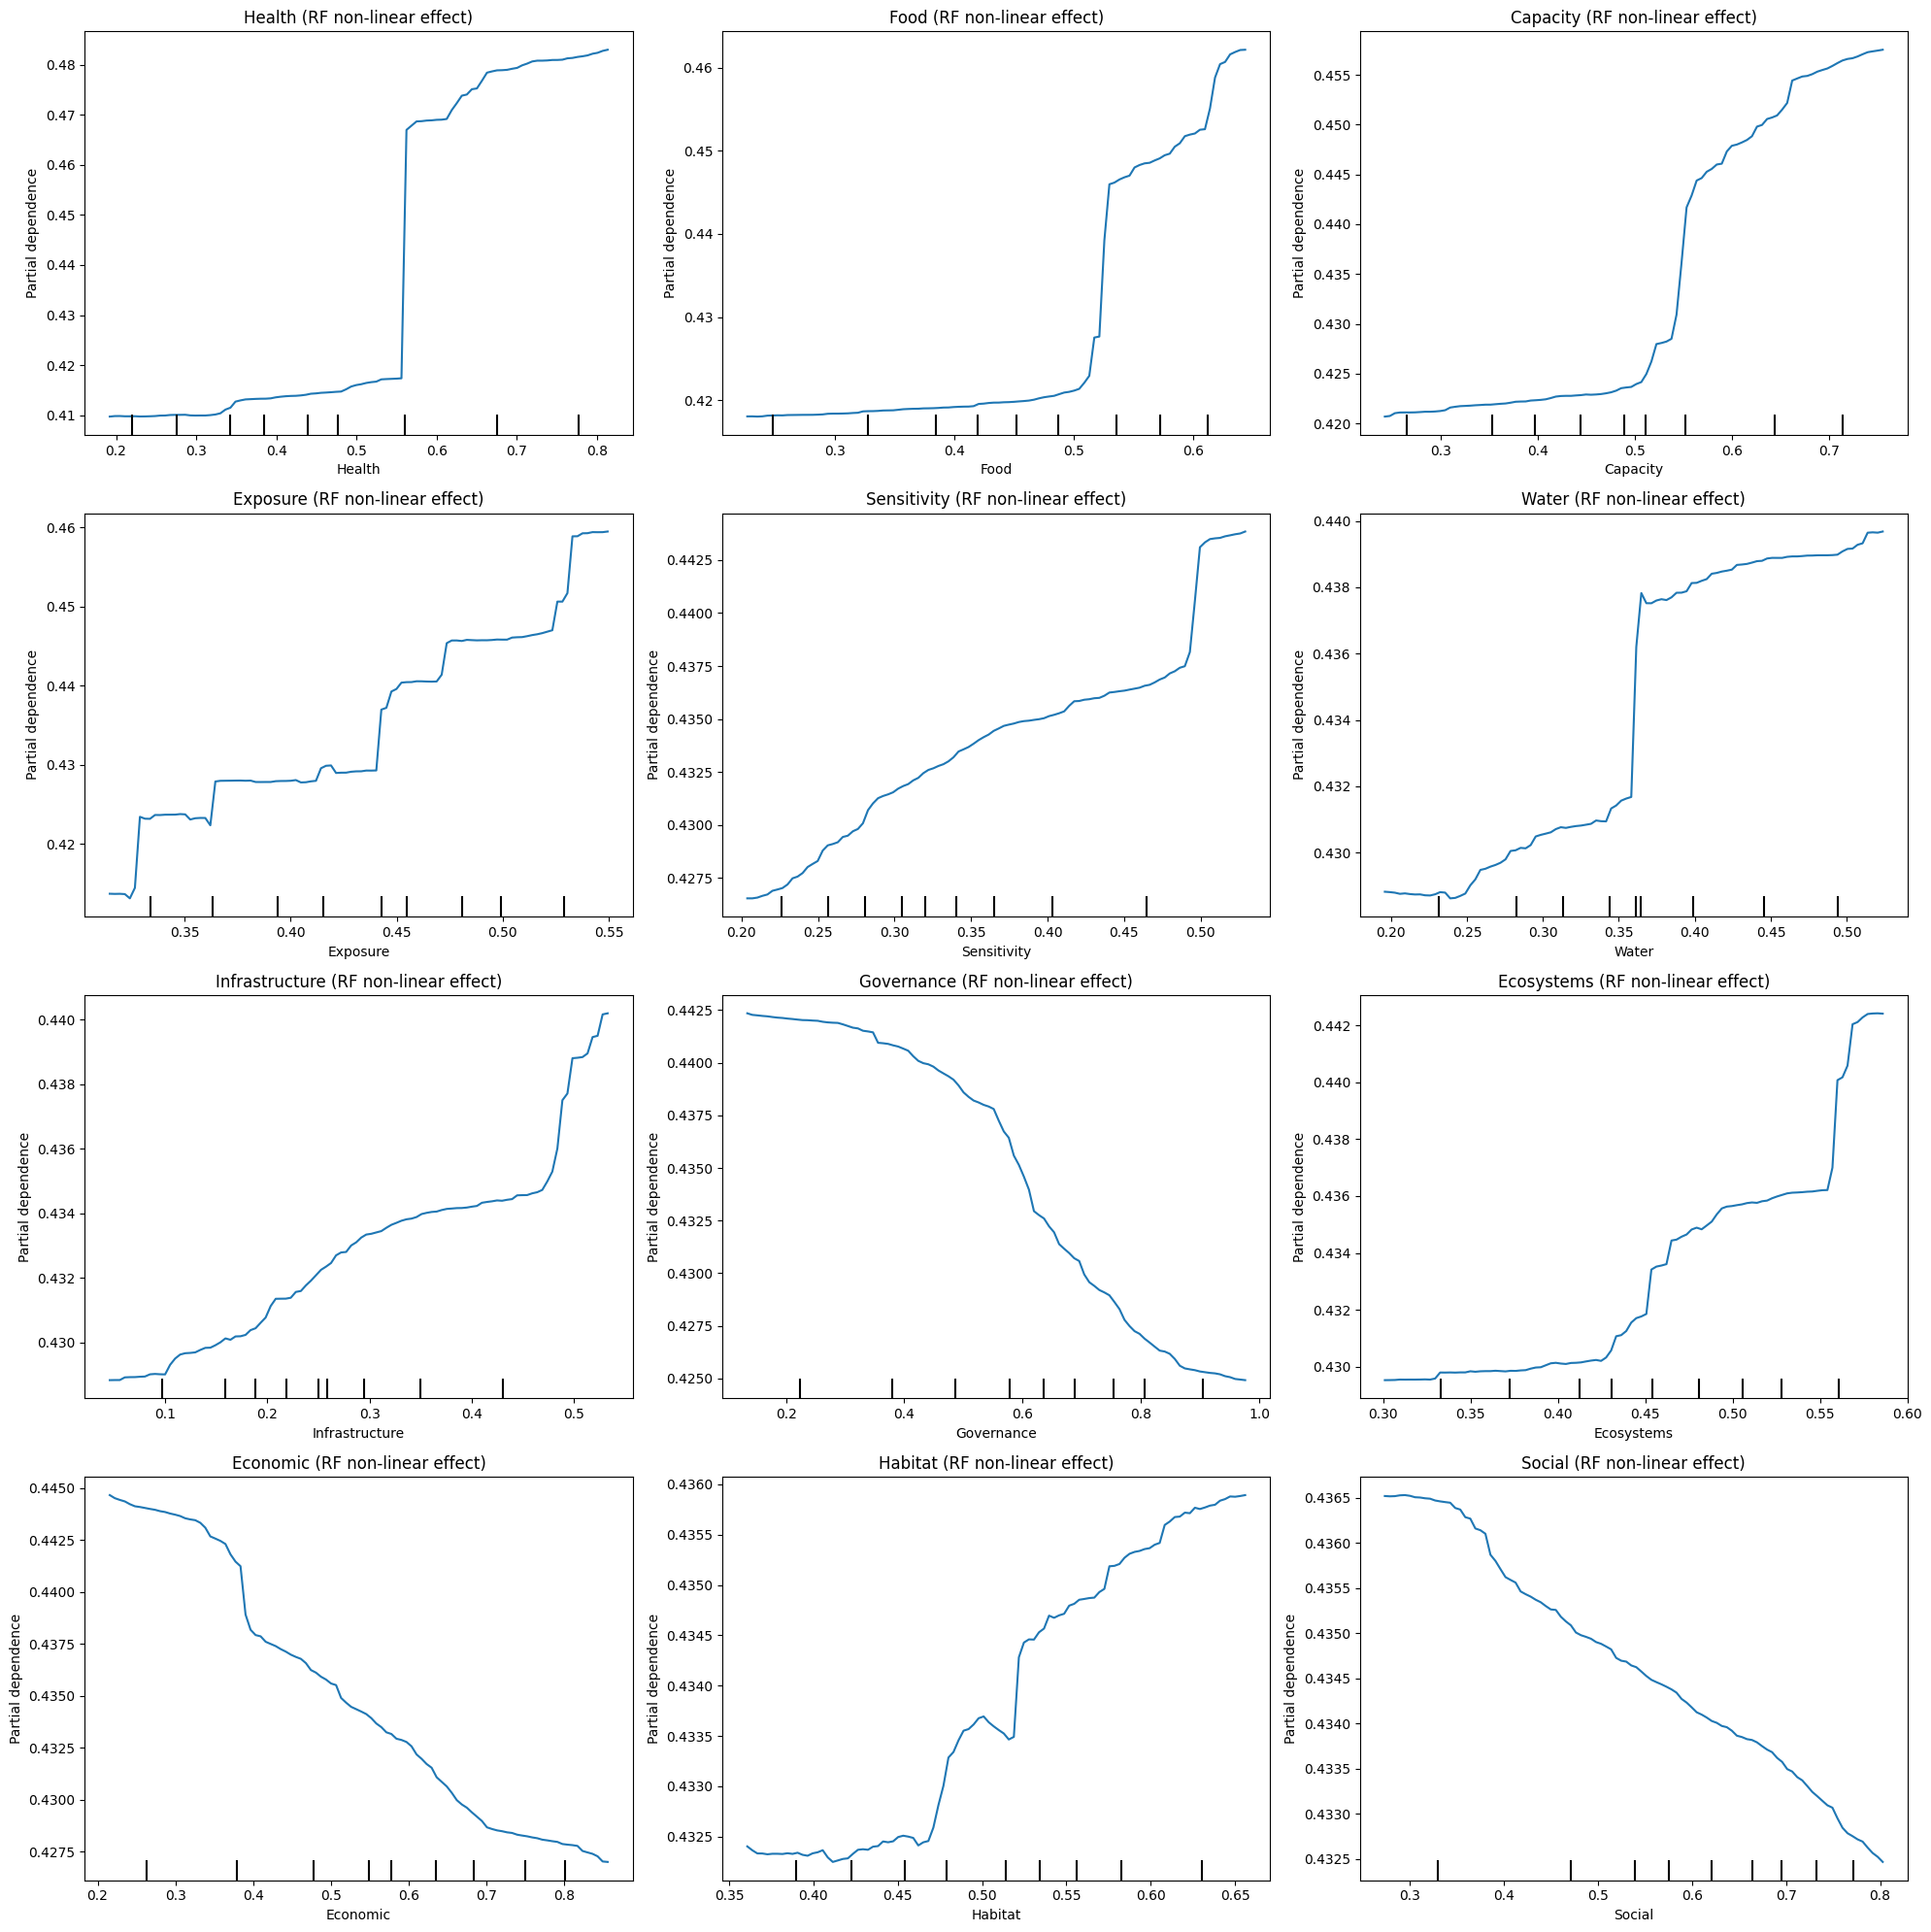

In [18]:
# Partial dependence plots for all features (original approach)
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
top_features_idx = importance_df.head(12).index.values

for idx, ax in enumerate(axes.flat):
    feature_idx = top_features_idx[idx]
    PartialDependenceDisplay.from_estimator(
        rf_corrected, X_corrected_test, [feature_idx], ax=ax
    )
    ax.set_title(f"{feature_names[feature_idx]} (RF non-linear effect)")

plt.tight_layout()
plt.show()

In [19]:
def explain_country_risk(country, model, explainer, data, year=None):

    # Get the requested row
    if year is None:
        row = data.loc[[country]].iloc[[0]]
    else:
        row = data.loc[[(country, year)]]

    # Prediction
    pred = model.predict(row)[0]

    # SHAP values
    shap_values = explainer.shap_values(row)

    explanation = (
        pd.DataFrame({
            "Feature": row.columns,
            "SHAP_Value": shap_values[0]
        })
        .sort_values("SHAP_Value", key=np.abs, ascending=False)
    )

    explanation["Contribution (%)"] = (
        explanation["SHAP_Value"].abs()
        / explanation["SHAP_Value"].abs().sum()
        * 100
    )

    print(f"\nPrediction: {pred:.4f}")
    print(f"Country: {row.index[0][0]}")
    print(f"Year: {row.index[0][1]}\n")

    return explanation

## 4. SHAP Model Interpretation
Interpret model predictions using SHAP. This section explains global importance, local explanations, and feature effects.

In [ ]:
"""Compute SHAP values for the trained Random Forest model.
SHAP values quantify each predictor\'s contribution to the predicted Composite Risk for every country-year observation."""

explainer = shap.TreeExplainer(rf_corrected)  # Your corrected RF model

# Calculate SHAP values for all data
shap_values = explainer.shap_values(X)

# Create base value (model's average prediction)
base_value = explainer.expected_value

explanation = shap.Explanation(
    values = shap_values,
    base_values=explainer.expected_value,
    feature_names=X.columns.tolist()
)

In [28]:
print(len(shap_values))
print(len(features))

8556
8556


<Figure size 1000x600 with 0 Axes>

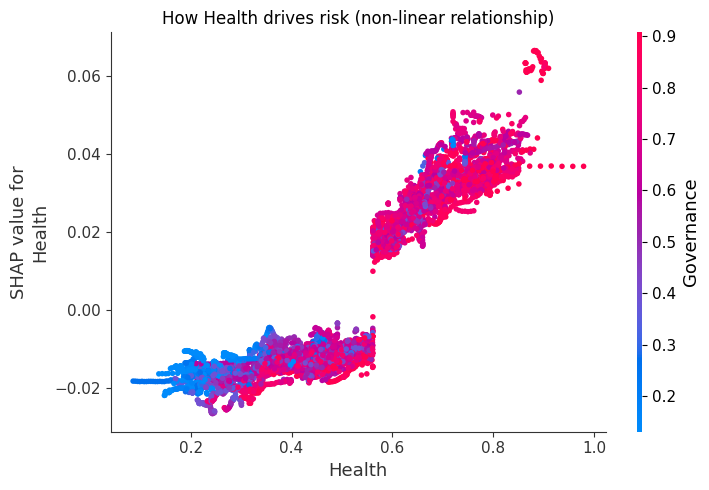

In [29]:
# COMMENTED OUT: This cell uses 'explainer' or 'shap_values' before they are created
# It will be enabled after SHAP analysis section
# Top contributor by SHAP impact
top_feature_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
top_feature_name = X.columns[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X,
    show=False
)
plt.title(f"How {top_feature_name} drives risk (non-linear relationship)")
plt.tight_layout()
plt.show()

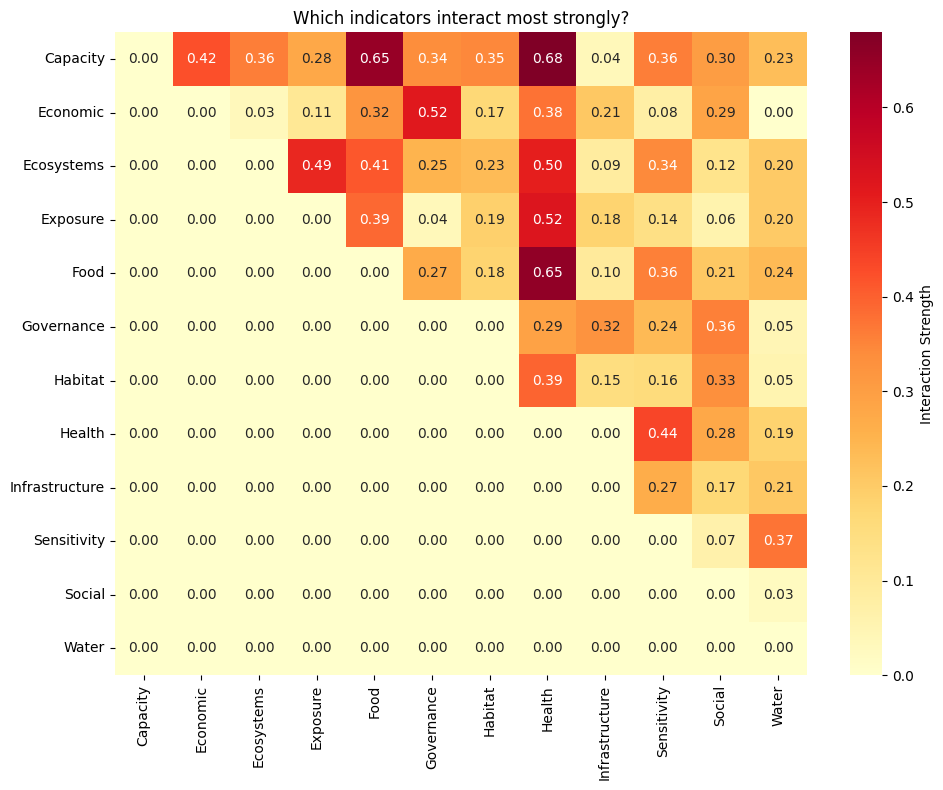

In [30]:


"""SHAP analysis restricted to the 12 base resilience components.
Vulnerability and Readiness are excluded because they are composite indicators."""
# Exclude Vulnerability and Readiness from this analysis
components = [col for col in X_corrected_test.columns
              if col not in ['Vulnerability', 'Readiness']]

explainer = shap.TreeExplainer(rf_corrected)
X_components_only = X_corrected_test[components]
shap_components = explainer.shap_values(X_components_only)


# ============ PLOT 2: Interaction heatmap ============
# Which component pairs interact most strongly?
interaction_matrix = np.zeros((len(components), len(components)))

for i, feat1 in enumerate(components):
    for j, feat2 in enumerate(components):
        if i < j:
            # Correlation between feature values × SHAP values = interaction proxy
            feat1_idx = X_corrected_test.columns.get_loc(feat1)
            feat2_idx = X_corrected_test.columns.get_loc(feat2)
            interaction = np.corrcoef(
                X_components_only[feat1].values,
                shap_components[:, feat2_idx]
            )[0, 1]
            interaction_matrix[i, j] = abs(interaction)

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(interaction_matrix, xticklabels=components, yticklabels=components,
            cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Interaction Strength'})
plt.title("Which indicators interact most strongly?")
plt.tight_layout()
plt.show()

In [28]:
rf_corrected.fit(X,y)
y_pred = rf_corrected.predict(X)


In [51]:
# Load saved PCA weights
weights_df = pd.read_csv("../../config/risk_score_weights.csv")

# Fix column names
weights_df = weights_df.rename(columns={"Unnamed: 0": "Feature"})

# Create RF importance table
rf_df = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_corrected.feature_importances_
})

# Merge with saved PC1 loadings
importance_df = (
    rf_df
    .merge(weights_df, on="Feature", how="left")
    .sort_values("RF_Importance", ascending=False)
)

print(importance_df)

           Feature  RF_Importance       PC1
7           Health       0.479488  0.371920
4             Food       0.151141  0.362303
0         Capacity       0.093623  0.380948
3         Exposure       0.084527  0.234249
5       Governance       0.035855  0.297012
9      Sensitivity       0.033706  0.283545
11           Water       0.030182  0.181449
8   Infrastructure       0.025454  0.117250
2       Ecosystems       0.025393  0.296086
1         Economic       0.023896  0.255446
6          Habitat       0.008579  0.263251
10          Social       0.008156  0.304816


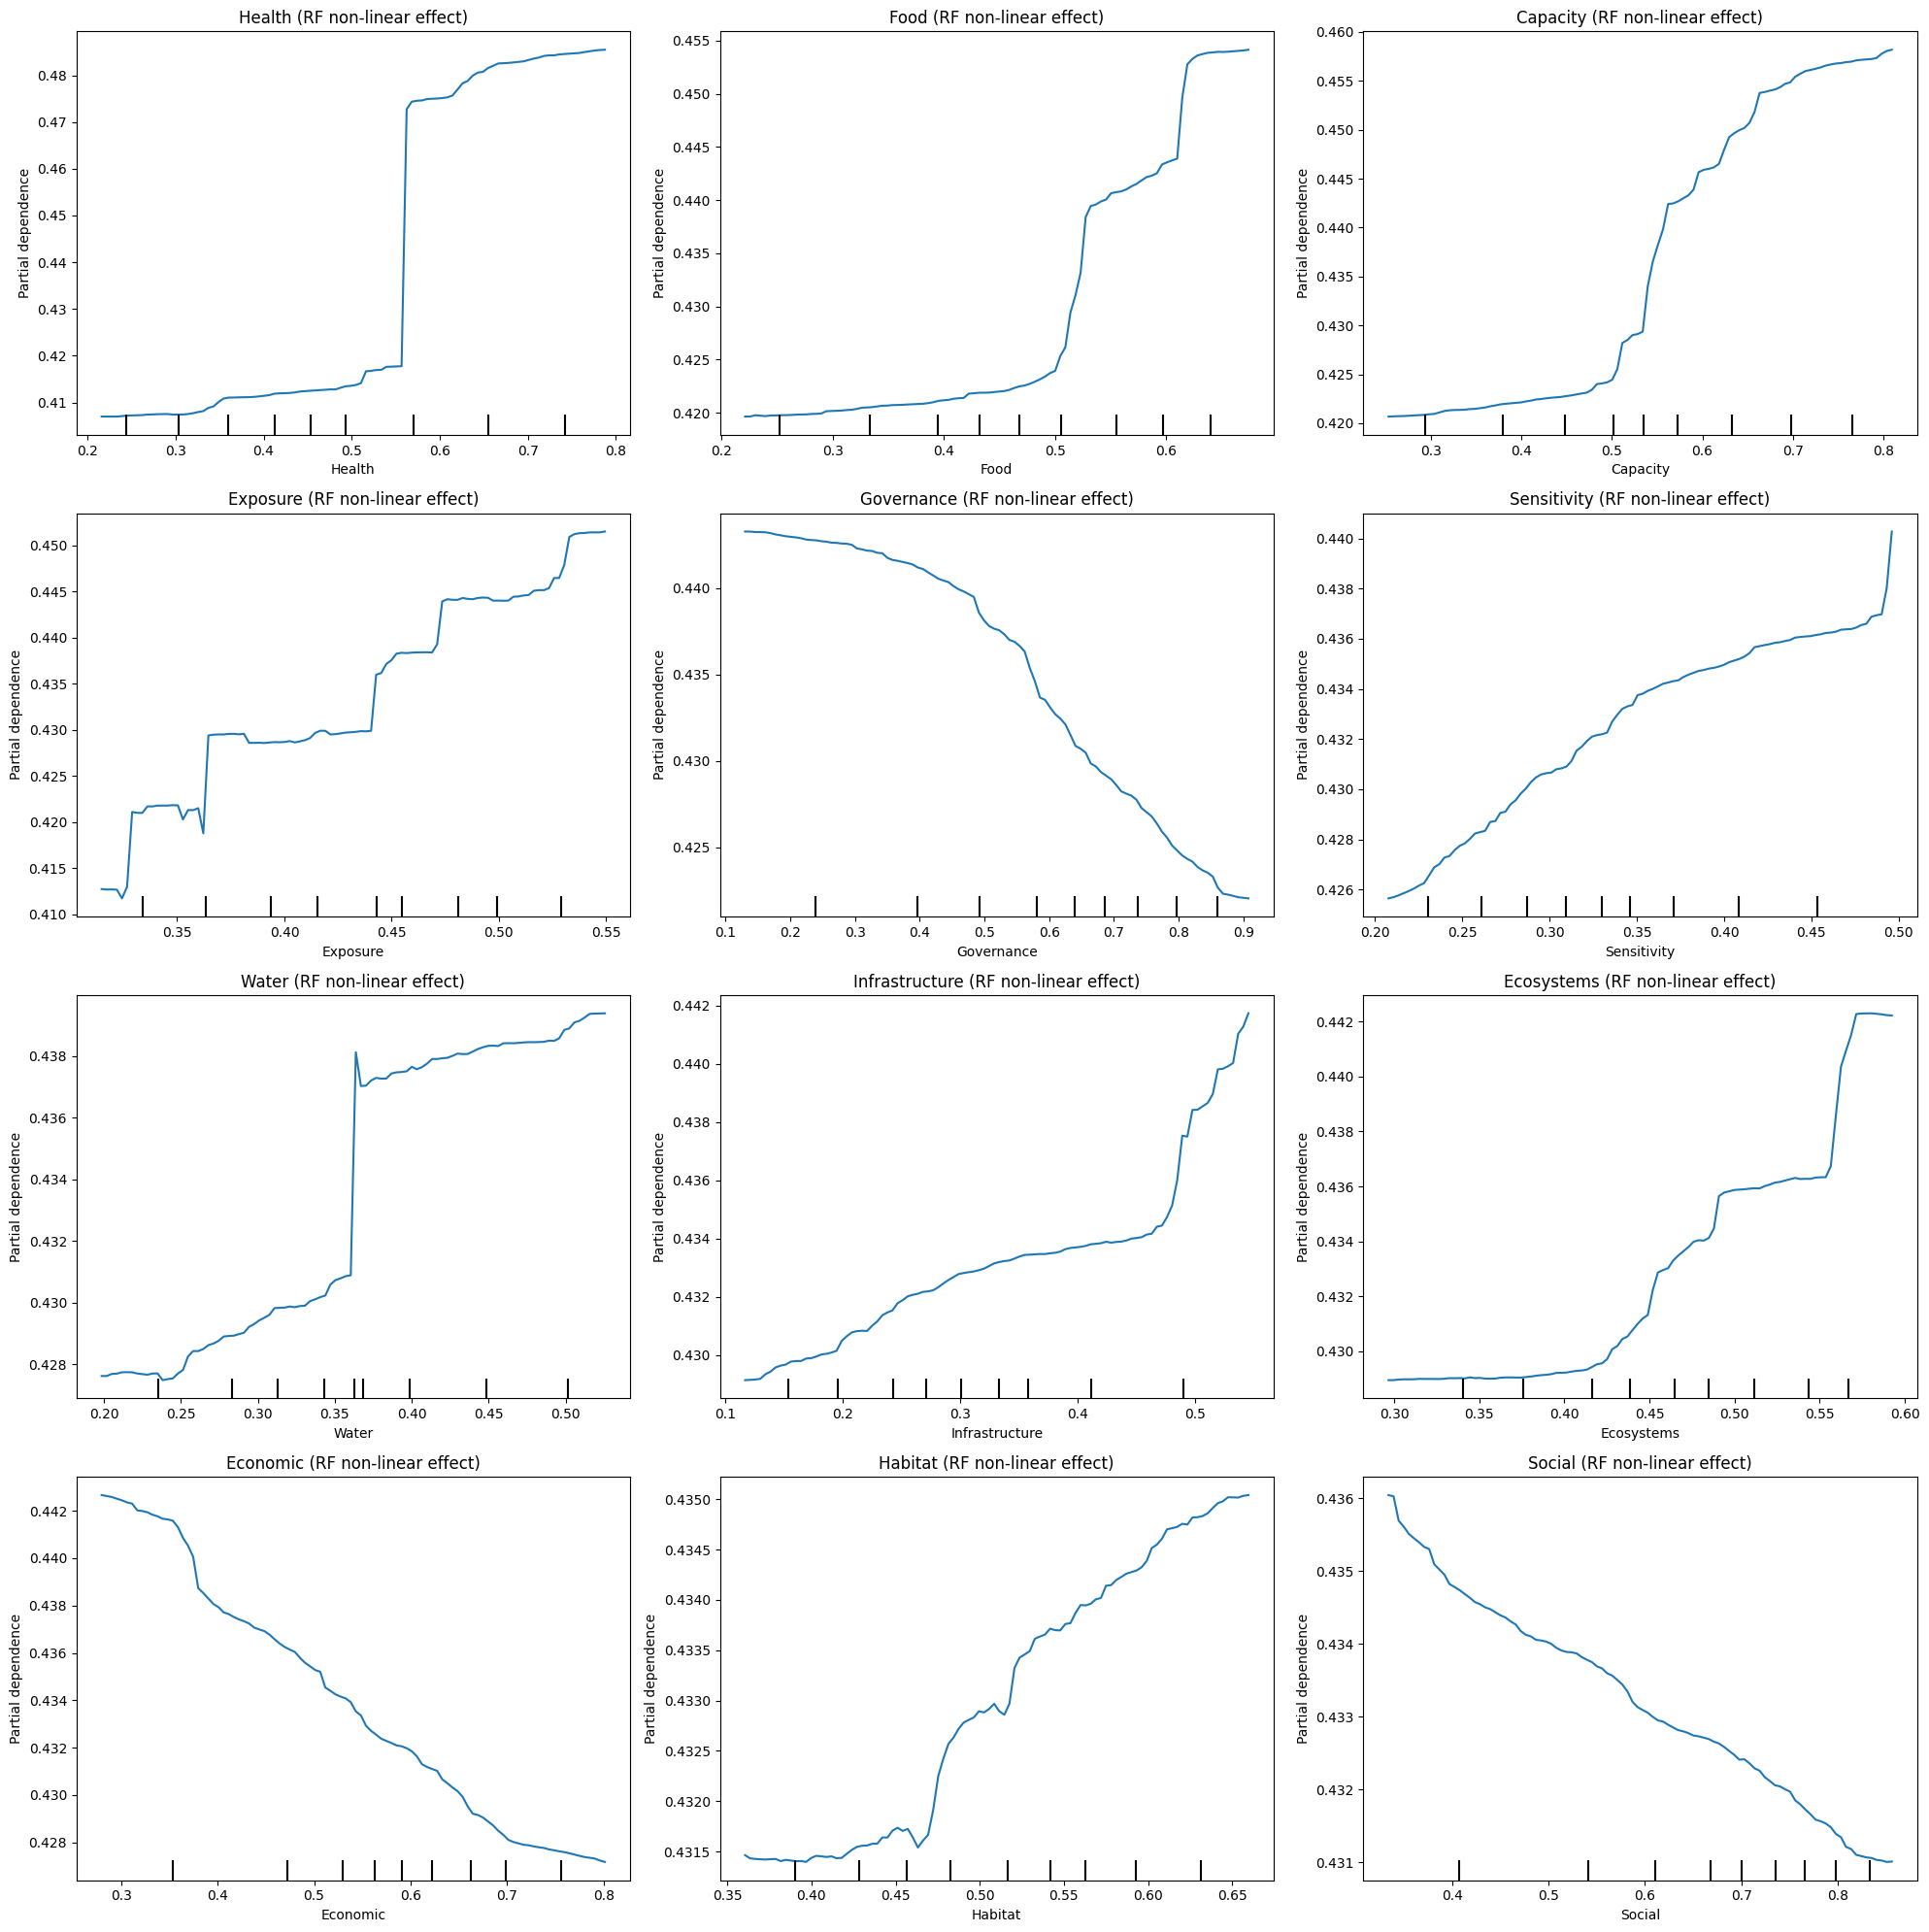

In [52]:
# Partial dependence plots for top 4 features (original approach)
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
top_features_idx = importance_df.head(12).index.values

for idx, ax in enumerate(axes.flat):
    feature_idx = top_features_idx[idx]
    PartialDependenceDisplay.from_estimator(
        rf_corrected, X, [feature_idx], ax=ax
    )
    ax.set_title(f"{feature_names[feature_idx]} (RF non-linear effect)")

plt.tight_layout()
plt.show()

In [53]:
"""Compute SHAP values for the trained Random Forest model.
SHAP values quantify each predictor\'s contribution to the predicted Composite Risk for every country-year observation."""

# Compute SHAP values for the trained Random Forest model.
# SHAP (SHapley Additive exPlanations) attributes each prediction
# to the contribution of every input feature.
explainer = shap.TreeExplainer(rf_corrected)  # Your corrected RF model

# Calculate SHAP values for all data
shap_values = explainer.shap_values(X)

# Create base value (model's average prediction)
base_value = explainer.expected_value

explanation = shap.Explanation(
    values = shap_values,
    base_values=explainer.expected_value,
    feature_names=X.columns.tolist()
)

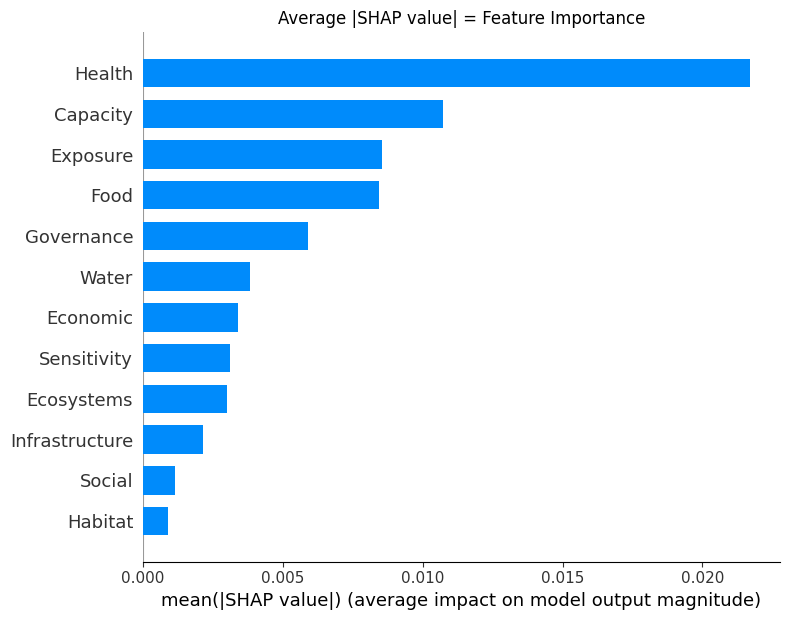

In [54]:
# Visualize global SHAP feature importance.: average absolute impact
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)
plt.title("Average |SHAP value| = Feature Importance")
plt.tight_layout()
plt.show()

In [55]:
X.iloc[0:10,:]

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     1995  0.893281  0.503503    0.515884  0.480512  0.665745    0.871910   
        1996  0.893892  0.503503    0.516995  0.480512  0.665583    0.871910   
        1997  0.894459  0.503503    0.518030  0.480512  0.665420    0.858608   
        1998  0.890161  0.503503    0.518156  0.480512  0.657103    0.845306   
        1999  0.885896  0.503503    0.518156  0.480512  0.648959    0.856311   
        2000  0.881523  0.503503    0.518156  0.480512  0.640726    0.867315   
        2001  0.871661  0.503503    0.518156  0.480512  0.631250    0.864948   
        2002  0.861821  0.503503    0.518156  0.480512  0.622440    0.862581   
        2003  0.852440  0.503503    0.518156  0.480512  0.614618    0.883977   
        2004  0.842772  0.503503    0.518156  0.480512  0.606118    0.885464   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.700042   
        1996  0.604235  0.748302        0.354484     0.419307  0.700046   
        1997  0.605583  0.748302        0.353925     0.419055  0.700048   
        1998  0.606909  0.748302        0.353710     0.418794  0.700051   
        1999  0.608137  0.748302        0.352292     0.419433  0.700053   
        2000  0.609171  0.748302        0.352891     0.419954  0.700054   
        2001  0.609941  0.747669        0.351845     0.420319  0.700054   
        2002  0.610407  0.747669        0.350372     0.420499  0.700004   
        2003  0.610594  0.700842        0.349830     0.397099  0.699645   
        2004  0.610599  0.722573        0.349232     0.407808  0.698996   

                 Water  
country year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
        2000  0.525637  
        2001  0.525648  
        2002  0.524336  
        2003  0.523046  
        2004  0.521640

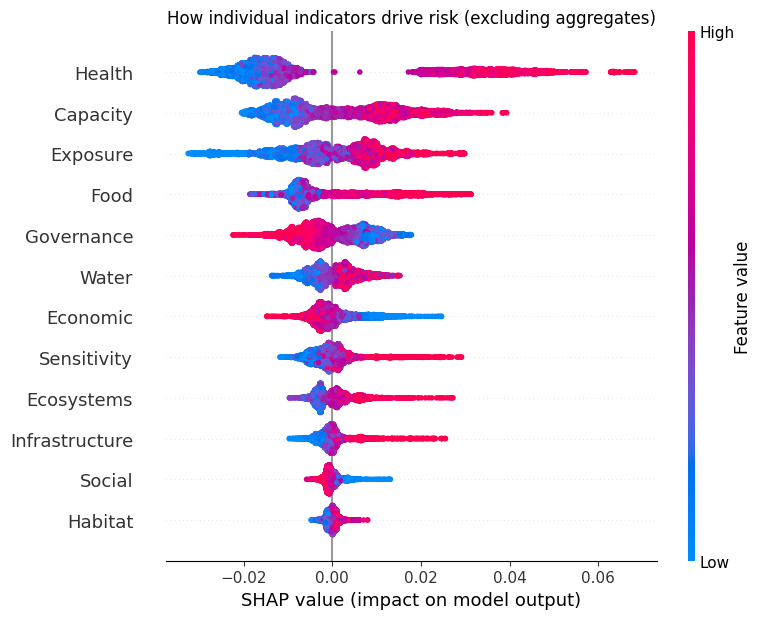

In [56]:
# Shows: high score → increases risk (right), low score → decreases risk (left)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X,
    plot_type="dot",
    show=False
)
plt.title("How individual indicators drive risk (excluding aggregates)")
plt.tight_layout()
plt.show()

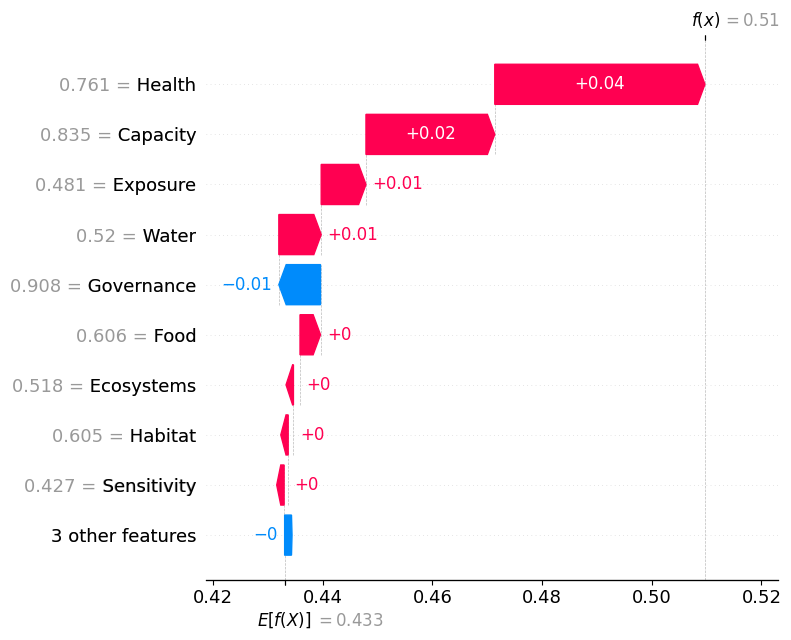

In [57]:
# Get SHAP values for a single country
country_idx = 10  # Pick a country
single_instance = X.iloc[country_idx:country_idx+1]
shap_values_single = explainer.shap_values(single_instance)

# Create waterfall plot correctly
explanation = shap.Explanation(
    values=shap_values_single[0],  # Get first (and only) row
    base_values=explainer.expected_value,
    data=single_instance.values[0],  # Convert to numpy array
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.show()

In [58]:
def explain_country_risk(country, model, explainer, data, year=None):

    # Get the requested row
    if year is None:
        row = data.loc[[country]].iloc[[0]]
    else:
        row = data.loc[[(country, year)]]

    # Prediction
    pred = model.predict(row)[0]

    # SHAP values
    shap_values = explainer.shap_values(row)

    explanation = (
        pd.DataFrame({
            "Feature": row.columns,
            "SHAP_Value": shap_values[0]
        })
        .sort_values("SHAP_Value", key=np.abs, ascending=False)
    )

    explanation["Contribution (%)"] = (
        explanation["SHAP_Value"].abs()
        / explanation["SHAP_Value"].abs().sum()
        * 100
    )

    print(f"\nPrediction: {pred:.4f}")
    print(f"Country: {row.index[0][0]}")
    print(f"Year: {row.index[0][1]}\n")

    return explanation

In [59]:
explain_country_risk("TCD", rf_corrected, explainer, X, year=2036)


Prediction: 0.5004
Country: TCD
Year: 2036



,Feature,SHAP_Value,Contribution (%)
7,Health,0.039419,39.852751
4,Food,0.013059,13.202664
0,Capacity,0.012055,12.187805
3,Exposure,0.009262,9.364336
5,Governance,-0.007711,7.796341
2,Ecosystems,0.006070,6.136766
1,Economic,-0.004401,4.449862
11,Water,0.002800,2.830741
9,Sensitivity,-0.001919,1.940172
8,Infrastructure,-0.001394,1.409424


<Figure size 1000x600 with 0 Axes>

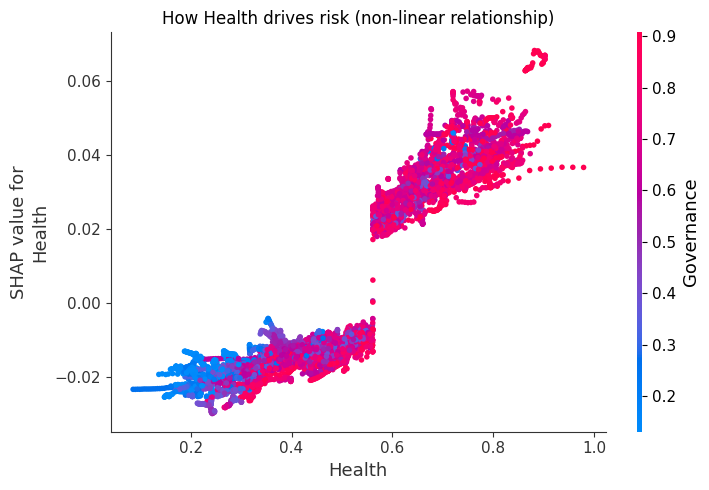

In [60]:
# Top contributor by SHAP impact
top_feature_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
top_feature_name = X.columns[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X,
    show=False
)
plt.title(f"How {top_feature_name} drives risk (non-linear relationship)")
plt.tight_layout()
plt.show()

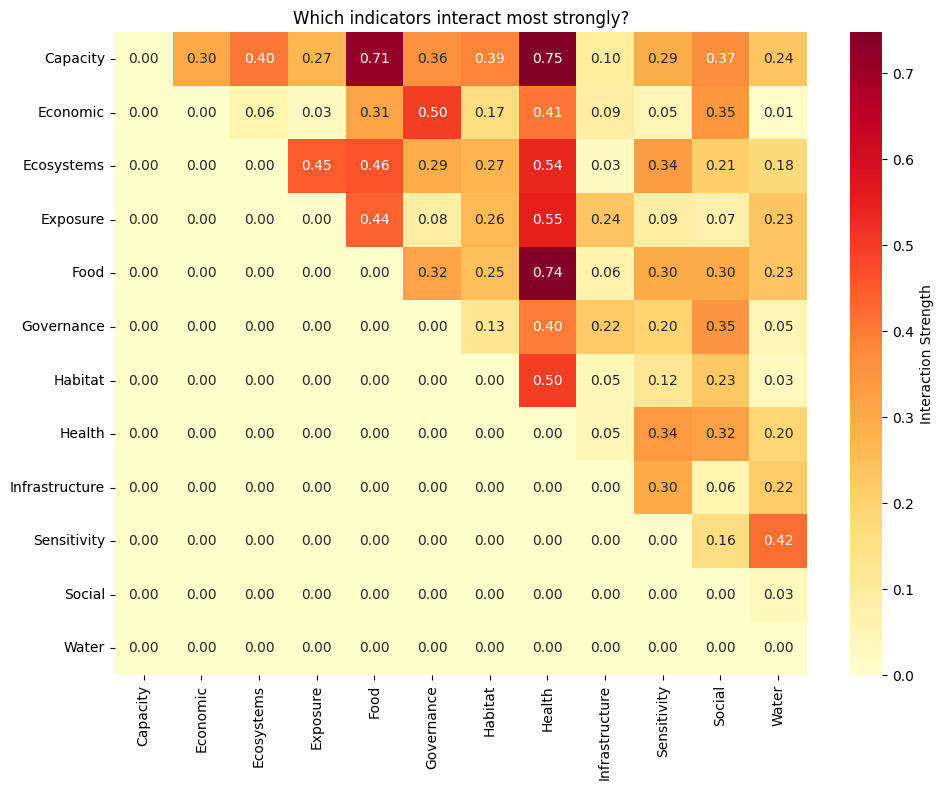

In [ ]:

"""SHAP analysis restricted to the 12 base resilience components.
Vulnerability and Readiness are excluded because they are composite indicators."""
# Exclude Vulnerability and Readiness from this analysis
components = [col for col in X.columns
              if col not in ['Vulnerability', 'Readiness']]

X_components_only = X[components]
shap_components = explainer.shap_values(X_components_only)


# ============ PLOT 2: Interaction heatmap ============
# Which component pairs interact most strongly?
interaction_matrix = np.zeros((len(components), len(components)))

for i, feat1 in enumerate(components):
    for j, feat2 in enumerate(components):
        if i < j:
            # Correlation between feature values × SHAP values = interaction proxy
            feat1_idx = X.columns.get_loc(feat1)
            feat2_idx = X.columns.get_loc(feat2)
            interaction = np.corrcoef(
                X_components_only[feat1].values,
                shap_components[:, feat2_idx]
            )[0, 1]
            interaction_matrix[i, j] = abs(interaction)

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(interaction_matrix, xticklabels=components, yticklabels=components,
            cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Interaction Strength'})
plt.title("Which indicators interact most strongly?")
plt.tight_layout()
plt.show()

In [62]:
X

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     1995  0.893281  0.503503    0.515884  0.480512  0.665745    0.871910   
        1996  0.893892  0.503503    0.516995  0.480512  0.665583    0.871910   
        1997  0.894459  0.503503    0.518030  0.480512  0.665420    0.858608   
        1998  0.890161  0.503503    0.518156  0.480512  0.657103    0.845306   
        1999  0.885896  0.503503    0.518156  0.480512  0.648959    0.856311   
...                ...       ...         ...       ...       ...         ...   
ZWE     2036  0.492703  0.739765    0.512340  0.516912  0.546805    0.870769   
        2037  0.486468  0.739768    0.512300  0.516912  0.545923    0.870928   
        2038  0.480233  0.739771    0.512266  0.516912  0.545040    0.871069   
        2039  0.473998  0.739773    0.512236  0.516912  0.544158    0.871192   
        2040  0.467763  0.739774    0.512210  0.516912  0.543276    0.871299   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.700042   
        1996  0.604235  0.748302        0.354484     0.419307  0.700046   
        1997  0.605583  0.748302        0.353925     0.419055  0.700048   
        1998  0.606909  0.748302        0.353710     0.418794  0.700051   
        1999  0.608137  0.748302        0.352292     0.419433  0.700053   
...                ...       ...             ...          ...       ...   
ZWE     2036  0.545288  0.697502        0.127529     0.444517  0.827124   
        2037  0.545246  0.697325        0.116114     0.446060  0.824706   
        2038  0.545212  0.697149        0.104699     0.447602  0.822288   
        2039  0.545186  0.696972        0.093284     0.449144  0.819871   
        2040  0.545164  0.696795        0.081868     0.450687  0.817453   

                 Water  
country year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
...                ...  
ZWE     2036  0.391843  
        2037  0.391844  
        2038  0.391845  
        2039  0.391845  
        2040  0.391846  

[8556 rows x 12 columns]

In [63]:
df

,country,indicator,year,value,source
0,AFG,Capacity,1995,0.893281,actual
1,AFG,Capacity,1996,0.893892,actual
2,AFG,Capacity,1997,0.894459,actual
3,AFG,Capacity,1998,0.890161,actual
4,AFG,Capacity,1999,0.885896,actual
...,...,...,...,...,...
128335,ZWE,Water,2036,0.391843,forecast
128336,ZWE,Water,2037,0.391844,forecast
128337,ZWE,Water,2038,0.391845,forecast
128338,ZWE,Water,2039,0.391845,forecast


In [66]:
components = [col for col in X.columns
              if col not in ['CompositeRisk']]

# Compatibility with different SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

In [ ]:
# SHAP values in wide format
feature_cols = components  # Preserve original model feature order

shap_df = pd.DataFrame(
    shap_values,
    index=X.index,
    columns=feature_cols
)

# Convert to long format
shap_long = (
    shap_df
    .stack()
    .reset_index()
    .rename(columns={
        "country": "Country",
        "year": "Year",
        "level_2": "Feature",
        0: "SHAP Value"
    })
)

In [67]:
shap_long

,Country,Year,Feature,SHAP Value
0,AFG,1995,Capacity,0.025980
1,AFG,1995,Economic,0.004082
2,AFG,1995,Ecosystems,0.001320
3,AFG,1995,Exposure,0.005015
4,AFG,1995,Food,0.020511
...,...,...,...,...
102667,ZWE,2040,Health,0.032345
102668,ZWE,2040,Infrastructure,-0.002740
102669,ZWE,2040,Sensitivity,0.000189
102670,ZWE,2040,Social,-0.003228


In [68]:
shap_long["SHAP Importance (%)"] = (
    shap_long.groupby(["Country", "Year"])["SHAP Value"]
    .transform(lambda x: x.abs() / x.abs().sum() * 100)
)

## 5. Global SHAP Feature Importance

In [69]:
shap_long = shap_long.sort_values(
    ["Country", "Year", "SHAP Importance (%)"],
    ascending=[True, True, False]
)

shap_long.to_csv(
    "country_feature_attribution.csv",
    index=False
)

In [70]:
shap_long[(shap_long["Country"]=='AFG') & (shap_long["Year"]==1995)]

,Country,Year,Feature,SHAP Value,SHAP Importance (%)
7,AFG,1995,Health,0.048783,41.521820
0,AFG,1995,Capacity,0.025980,22.112825
4,AFG,1995,Food,0.020511,17.458416
5,AFG,1995,Governance,-0.005737,4.882981
3,AFG,1995,Exposure,0.005015,4.268805
11,AFG,1995,Water,0.004121,3.507570
1,AFG,1995,Economic,0.004082,3.474292
2,AFG,1995,Ecosystems,0.001320,1.123313
9,AFG,1995,Sensitivity,-0.000917,0.780705
6,AFG,1995,Habitat,0.000548,0.466442


In [71]:
global_feature_importance = (
    pd.DataFrame({
        "Feature": X_components_only.columns,
        "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("Mean |SHAP|", ascending=False)
)

In [72]:
global_feature_importance["Importance (%)"] = (
    global_feature_importance["Mean |SHAP|"]
    / global_feature_importance["Mean |SHAP|"].sum()
    * 100
)

In [73]:
print(len(X_components_only.columns))

12


In [74]:
global_feature_importance.to_csv(
    "global_feature_importance.csv",
    index=False
)

In [75]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_feature_importance = pd.DataFrame({
    "Feature": X_components_only.columns,
    "RF Importance": rf_corrected.feature_importances_*100,
    "Mean |SHAP|": mean_abs_shap
})

global_feature_importance["SHAP Importance (%)"] = (
    global_feature_importance["Mean |SHAP|"]
    / global_feature_importance["Mean |SHAP|"].sum()
    *100
)

global_feature_importance = global_feature_importance.sort_values(
    "SHAP Importance (%)",
    ascending=False
).reset_index(drop=True)

global_feature_importance.to_csv(
    "global_feature_importance.csv",
    index=False
)

global_feature_importance

,Feature,RF Importance,Mean |SHAP|,SHAP Importance (%)
0,Health,47.948756,0.021688,29.795282
1,Capacity,9.362322,0.010722,14.729772
2,Exposure,8.452719,0.008548,11.742667
3,Food,15.114147,0.008433,11.585012
4,Governance,3.585484,0.005905,8.111930
5,Water,3.018173,0.003810,5.233966
6,Economic,2.389644,0.003389,4.655833
7,Sensitivity,3.370573,0.003104,4.263655
8,Ecosystems,2.539268,0.002992,4.110273
9,Infrastructure,2.545441,0.002163,2.972022


## 6. Feature Dependence Analysis
Relate each feature's value to its SHAP contribution across all country-year observations.

# PARTIAL DEPENDENCIES

In [76]:
X_components_long = (
    X_components_only
    .reset_index()
    .rename(columns={
        "country": "Country",
        "year": "Year"
    })
)

In [77]:
X_components_long

,Country,Year,Capacity,Economic,Ecosystems,Exposure,Food,Governance,Habitat,Health,Infrastructure,Sensitivity,Social,Water
0,AFG,1995,0.893281,0.503503,0.515884,0.480512,0.665745,0.871910,0.602933,0.748302,0.355586,0.419587,0.700042,0.529692
1,AFG,1996,0.893892,0.503503,0.516995,0.480512,0.665583,0.871910,0.604235,0.748302,0.354484,0.419307,0.700046,0.528281
2,AFG,1997,0.894459,0.503503,0.518030,0.480512,0.665420,0.858608,0.605583,0.748302,0.353925,0.419055,0.700048,0.526853
3,AFG,1998,0.890161,0.503503,0.518156,0.480512,0.657103,0.845306,0.606909,0.748302,0.353710,0.418794,0.700051,0.525424
4,AFG,1999,0.885896,0.503503,0.518156,0.480512,0.648959,0.856311,0.608137,0.748302,0.352292,0.419433,0.700053,0.525585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8551,ZWE,2036,0.492703,0.739765,0.512340,0.516912,0.546805,0.870769,0.545288,0.697502,0.127529,0.444517,0.827124,0.391843
8552,ZWE,2037,0.486468,0.739768,0.512300,0.516912,0.545923,0.870928,0.545246,0.697325,0.116114,0.446060,0.824706,0.391844
8553,ZWE,2038,0.480233,0.739771,0.512266,0.516912,0.545040,0.871069,0.545212,0.697149,0.104699,0.447602,0.822288,0.391845
8554,ZWE,2039,0.473998,0.739773,0.512236,0.516912,0.544158,0.871192,0.545186,0.696972,0.093284,0.449144,0.819871,0.391845


In [78]:
feature_values = (
    X_components_long
    .melt(
        id_vars=["Country", "Year"],
        var_name="Feature",
        value_name="Feature Value"
    )
)

In [79]:
feature_values

,Country,Year,Feature,Feature Value
0,AFG,1995,Capacity,0.893281
1,AFG,1996,Capacity,0.893892
2,AFG,1997,Capacity,0.894459
3,AFG,1998,Capacity,0.890161
4,AFG,1999,Capacity,0.885896
...,...,...,...,...
102667,ZWE,2036,Water,0.391843
102668,ZWE,2037,Water,0.391844
102669,ZWE,2038,Water,0.391845
102670,ZWE,2039,Water,0.391845


In [80]:
shap_long

,Country,Year,Feature,SHAP Value,SHAP Importance (%)
7,AFG,1995,Health,0.048783,41.521820
0,AFG,1995,Capacity,0.025980,22.112825
4,AFG,1995,Food,0.020511,17.458416
5,AFG,1995,Governance,-0.005737,4.882981
3,AFG,1995,Exposure,0.005015,4.268805
...,...,...,...,...,...
102670,ZWE,2040,Social,-0.003228,3.444843
102668,ZWE,2040,Infrastructure,-0.002740,2.924807
102671,ZWE,2040,Water,0.001594,1.700786
102666,ZWE,2040,Habitat,-0.000691,0.737926


In [81]:
feature_dependence = feature_values.merge(
    shap_long,
    on=["Country", "Year", "Feature"],
    how="left"
)

In [82]:
feature_dependence["SHAP Importance (%)"] = (
    feature_dependence
    .groupby(["Country", "Year"])["SHAP Value"]
    .transform(lambda x: x.abs() / x.abs().sum() * 100)
)

In [96]:
metrics = df.rename(columns={
    "country": "Country",
    "year": "Year",
    "indicator": "Indicator",
    "value": "Value"
})

metrics = (
    metrics[metrics["Indicator"].isin(["Readiness", "Vulnerability", "CompositeRisk"])]
    .pivot(
        index=["Country", "Year"],
        columns="Indicator",
        values="Value"
    )
    .reset_index()
)


In [97]:
feature_dependence = feature_dependence.merge(
    metrics[
        [
            "Country",
            "Year",
            "Readiness",
            "Vulnerability",
            "CompositeRisk"
        ]
    ],
    on=["Country", "Year"],
    how="left"
)

In [98]:
feature_dependence = feature_dependence.sort_values(
    ["Country", "Year", "SHAP Importance (%)"],
    ascending=[True, True, False]
).reset_index(drop=True)

In [99]:
feature_dependence.to_csv(
    "feature_dependence.csv",
    index=False
)